<a href="https://colab.research.google.com/github/khrystynakoblan/GazeEstimation/blob/main/source/gaze_estimation_main_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Встановлення бібліотек
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 -q
!pip install scipy matplotlib scikit-learn tqdm kagglehub -q
print("Бібліотеки встановлено")

Бібліотеки встановлено


In [ ]:
# Імпорти та seed
import random
import copy
import warnings

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from scipy.ndimage import uniform_filter1d

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

warnings.filterwarnings('ignore')

print(f"PyTorch версія: {torch.__version__}")
print(f"CUDA доступна: {torch.cuda.is_available()}")


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)
print("Seed встановлено для відтворюваності")

PyTorch версія: 2.10.0+cu128
CUDA доступна: True
Seed встановлено для відтворюваності


In [ ]:
# Завантаження датасету

import kagglehub
import subprocess

dataset_path = kagglehub.dataset_download("dhruv413/mpiigaze")
print(f"Датасет завантажено: {dataset_path}")

result = subprocess.run(
    ['find', dataset_path, '-type', 'f', '-name', '*.mat'],
    capture_output=True, text=True
)
print('\n'.join(result.stdout.strip().split('\n')[:5]))

Download already complete (2228240591 bytes).
Extracting files...
Датасет завантажено: /root/.cache/kagglehub/datasets/dhruv413/mpiigaze/versions/1
/root/.cache/kagglehub/datasets/dhruv413/mpiigaze/versions/1/MPIIGaze/6 points-based face model.mat
/root/.cache/kagglehub/datasets/dhruv413/mpiigaze/versions/1/MPIIGaze/Data/Original/p11/Calibration/screenSize.mat
/root/.cache/kagglehub/datasets/dhruv413/mpiigaze/versions/1/MPIIGaze/Data/Original/p11/Calibration/Camera.mat
/root/.cache/kagglehub/datasets/dhruv413/mpiigaze/versions/1/MPIIGaze/Data/Original/p11/Calibration/monitorPose.mat
/root/.cache/kagglehub/datasets/dhruv413/mpiigaze/versions/1/MPIIGaze/Data/Original/p05/Calibration/screenSize.mat


In [ ]:
# Аналіз структури MPIIGaze

norm_path = Path(dataset_path) / "MPIIGaze" / "Data" / "Normalized"
all_participants = sorted([d.name for d in norm_path.iterdir() if d.is_dir()])
print(f"Учасників: {len(all_participants)} → {all_participants}")

mat_files = list((norm_path / all_participants[0]).glob("*.mat"))
data = sio.loadmat(str(mat_files[0]))
right_eye = data['data'][0, 0]['right'][0, 0]
print(f"\nПраве око: {right_eye.dtype.names}")
for f in right_eye.dtype.names:
    print(f"  '{f}': {right_eye[f].shape}")

Учасників: 15 → ['p00', 'p01', 'p02', 'p03', 'p04', 'p05', 'p06', 'p07', 'p08', 'p09', 'p10', 'p11', 'p12', 'p13', 'p14']

Праве око: ('gaze', 'image', 'pose')
  'gaze': (920, 3)
  'image': (920, 36, 60)
  'pose': (920, 3)


In [ ]:
# Dataset клас

class MPIIGazeDataset(Dataset):
    def __init__(self, root_path, participants, split='train', eyes='both',
                 samples_per_participant=2000, transform=None, gaze_ranges=None,
                 img_mean=0.0, img_std=1.0):
        super().__init__()
        self.root_path = Path(root_path)
        self.participants = participants
        self.split = split
        self.eyes = eyes
        self.samples_per_participant = samples_per_participant
        self.transform = transform if split == 'train' else None
        self.gaze_ranges = gaze_ranges
        self.img_mean = img_mean
        self.img_std = img_std

        self.images = []
        self.gazes_2d = []
        self.gazes_3d = []
        self.poses = []
        self.participant_ids = []
        self.eye_labels = []

        self._load_data()

        if self.gaze_ranges is None:
            self._compute_and_apply_normalization()
        else:
            self._apply_existing_normalization()

        print(f"{split.upper()} Dataset: {len(self.images)} зразків")

    def _compute_and_apply_normalization(self):
        gazes = np.array(self.gazes_2d, dtype=np.float32)
        yaw_min, yaw_max = gazes[:, 0].min(), gazes[:, 0].max()
        pit_min, pit_max = gazes[:, 1].min(), gazes[:, 1].max()
        yaw_abs = max(abs(yaw_min), abs(yaw_max)) * 1.05
        pit_abs = max(abs(pit_min), abs(pit_max)) * 1.05
        self.gaze_ranges = {
            'yaw':   (-yaw_abs, yaw_abs),
            'pitch': (-pit_abs, pit_abs),
        }

        print(f"\n[POOL] Обчислені діапазони:")
        print(f"  yaw:   [{self.gaze_ranges['yaw'][0]:.4f}, {self.gaze_ranges['yaw'][1]:.4f}] рад")
        print(f"  pitch: [{self.gaze_ranges['pitch'][0]:.4f}, {self.gaze_ranges['pitch'][1]:.4f}] рад")
        self._normalize_gazes()

    def _apply_existing_normalization(self):
        self._normalize_gazes()
        vmin = np.min(self.gazes_2d_normalized)
        vmax = np.max(self.gazes_2d_normalized)
        out_of = np.sum(np.abs(self.gazes_2d_normalized) > 1.0)
        print(f"\n[{self.split.upper()}] Використано зовнішні діапазони:")
        print(f"  Діапазон після норм.: [{vmin:.3f}, {vmax:.3f}]")
        if out_of > 0:
            pct = out_of / len(self.gazes_2d_normalized) / 2 * 100
            print(f"  За межами [-1,1]: {out_of} ({pct:.1f}%)")

    def _normalize_gazes(self):
        gazes = np.array(self.gazes_2d, dtype=np.float32)
        self.gazes_2d_normalized = np.zeros_like(gazes)
        ymin, ymax = self.gaze_ranges['yaw']
        pmin, pmax = self.gaze_ranges['pitch']
        self.gazes_2d_normalized[:, 0] = 2 * (gazes[:, 0] - ymin) / (ymax - ymin) - 1
        self.gazes_2d_normalized[:, 1] = 2 * (gazes[:, 1] - pmin) / (pmax - pmin) - 1
        if self.split == 'train':
            self.gazes_2d_normalized = np.clip(self.gazes_2d_normalized, -1.0, 1.0)

    def normalize_gaze(self, gaze_2d):
        ymin, ymax = self.gaze_ranges['yaw']
        pmin, pmax = self.gaze_ranges['pitch']
        out = np.array([
            2 * (gaze_2d[0] - ymin) / (ymax - ymin) - 1,
            2 * (gaze_2d[1] - pmin) / (pmax - pmin) - 1,
        ], dtype=np.float32)
        if self.split == 'train':
            out = np.clip(out, -1.0, 1.0)
        return out

    def denormalize_gaze(self, norm_gaze):
        ymin, ymax = self.gaze_ranges['yaw']
        pmin, pmax = self.gaze_ranges['pitch']
        return np.array([
            (norm_gaze[0] + 1) * (ymax - ymin) / 2 + ymin,
            (norm_gaze[1] + 1) * (pmax - pmin) / 2 + pmin,
        ], dtype=np.float32)


    @staticmethod
    def gaze_3d_to_2d(gaze_3d):
        x, y, z = gaze_3d
        if abs(z) < 1e-6:
            z = 1e-6 * (1 if z >= 0 else -1)
        yaw   = np.arctan2(-x, -z)
        pitch = np.arctan2(-y, np.sqrt(x**2 + z**2))
        return np.array([yaw, pitch], dtype=np.float32)

    def _load_data(self):
        norm_path = self.root_path / "MPIIGaze" / "Data" / "Normalized"
        if not norm_path.exists():
            norm_path = self.root_path / "Data" / "Normalized"

        print(f"\nЗавантаження для {len(self.participants)} учасників...")
        participant_counter = 0

        for participant in self.participants:
            participant_path = norm_path / participant
            if not participant_path.exists():
                print(f"  {participant}: не знайдено")
                continue

            mat_files = sorted(list(participant_path.glob("*.mat")))
            if not mat_files:
                continue

            print(f"\n{participant}: {len(mat_files)} файлів")
            participant_samples = 0
            samples_per_eye = (self.samples_per_participant // 2
                               if self.eyes == 'both' else self.samples_per_participant)
            eye_count = {'right': 0, 'left': 0}
            eyes_to_proc = ['right', 'left'] if self.eyes == 'both' else [self.eyes]

            for mat_file in mat_files:
                if participant_samples >= self.samples_per_participant:
                    break
                try:
                    data = sio.loadmat(str(mat_file))
                except Exception as e:
                    print(f"  {mat_file.name}: {e}")
                    continue

                for eye_type in eyes_to_proc:
                    if eye_count[eye_type] >= samples_per_eye:
                        continue
                    try:
                        eye_data = data['data'][0, 0][eye_type][0, 0]
                        if not (hasattr(eye_data, 'dtype') and 'image' in eye_data.dtype.names):
                            continue

                        images   = eye_data['image']
                        gazes_3d = eye_data['gaze']
                        poses_3d = eye_data['pose']
                        n = images.shape[0]
                        if n == 0:
                            continue

                        n_to_take = min(samples_per_eye - eye_count[eye_type], n)
                        chosen = np.random.choice(n, n_to_take, replace=False)
                        added = 0

                        for i in chosen:
                            if participant_samples >= self.samples_per_participant:
                                break

                            img = images[i].astype(np.float32)
                            if img.max() > 1.0:
                                img /= 255.0

                            gaze_3d = gazes_3d[i].astype(np.float32)
                            pose_3d = poses_3d[i].astype(np.float32)

                            if eye_type == 'left':
                                img = img[:, ::-1].copy()
                                gaze_3d[0] = -gaze_3d[0]
                                pose_3d[1] = -pose_3d[1]
                                pose_3d[2] = -pose_3d[2]

                            gaze_2d = self.gaze_3d_to_2d(gaze_3d)
                            if np.any(np.isnan(gaze_2d)):
                                continue

                            self.images.append(img)
                            self.gazes_2d.append(gaze_2d)
                            self.gazes_3d.append(gaze_3d)
                            self.poses.append(pose_3d)
                            self.participant_ids.append(participant_counter)
                            self.eye_labels.append(0 if eye_type == 'right' else 1)

                            participant_samples += 1
                            added += 1
                            eye_count[eye_type] += 1

                        print(f"  {eye_type}: +{added} (всього {eye_count[eye_type]})")
                    except Exception as e:
                        print(f"  {eye_type}: {str(e)[:80]}")

            print(f"  {participant}: {participant_samples} зразків")
            participant_counter += 1

        if not self.images:
            print("Dataset порожній!")
            return

        self.images          = np.array(self.images,          dtype=np.float32)
        self.gazes_2d        = np.array(self.gazes_2d,        dtype=np.float32)
        self.gazes_3d        = np.array(self.gazes_3d,        dtype=np.float32)
        self.poses           = np.array(self.poses,           dtype=np.float32)
        self.participant_ids = np.array(self.participant_ids, dtype=np.int32)
        self.eye_labels      = np.array(self.eye_labels,      dtype=np.int32)

        print(f"\n{len(self.images)} зразків | "
              f"Праве: {np.sum(self.eye_labels==0)}, "
              f"Ліве: {np.sum(self.eye_labels==1)}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img      = self.images[idx].copy()
        gaze_raw = self.gazes_2d[idx].copy()
        pose     = self.poses[idx].copy()

        if len(img.shape) == 2:
            img = np.expand_dims(img, axis=0)

        img_tensor = (torch.from_numpy(img).float() - self.img_mean) / self.img_std

        if self.split == 'train' and self.transform is not None:
            if random.random() > 0.5:
                img_tensor = torch.flip(img_tensor, dims=[2])
                gaze_raw[0] = -gaze_raw[0]
                pose[1] = -pose[1]
                pose[2] = -pose[2]
            img_tensor = self.transform(img_tensor)

        pose_tensor = torch.from_numpy(pose).float()

        gaze_norm = self.normalize_gaze(gaze_raw)
        gaze_tensor = torch.from_numpy(gaze_norm).float()

        metadata = {
            'participant_id': self.participant_ids[idx],
            'eye_label':      self.eye_labels[idx],
            'gaze_3d':        self.gazes_3d[idx].copy(),
            'gaze_original':  gaze_raw,
            'pose':           pose,
        }
        return img_tensor, gaze_tensor, pose_tensor, metadata

In [ ]:
# Підготовка даних та CV-розбивка
print("Підготовка даних...")

all_participants  = [f'p{i:02d}' for i in range(15)]
test_participants = all_participants[13:]   # p13, p14
cv_participants   = all_participants[:13]   # p00–p12

print("\nОбчислення глобальних статистик з пулу p00-p12...")
_pool_ds = MPIIGazeDataset(
    root_path=dataset_path,
    participants=cv_participants,
    split='train',
    eyes='both',
    samples_per_participant=2000,
)
IMG_MEAN          = float(np.mean(_pool_ds.images))
IMG_STD           = max(float(np.std(_pool_ds.images)), 1e-6)
GLOBAL_GAZE_RANGES = _pool_ds.gaze_ranges
del _pool_ds

print(f"\nГЛОБАЛЬНІ СТАТИСТИКИ:")
print(f"  IMG_MEAN = {IMG_MEAN:.4f}")
print(f"  IMG_STD  = {IMG_STD:.4f}")
print(f"  gaze_ranges[yaw]:   {GLOBAL_GAZE_RANGES['yaw']}")
print(f"  gaze_ranges[pitch]: {GLOBAL_GAZE_RANGES['pitch']}")

n_folds   = 5
cv_chunks = np.array_split(cv_participants, n_folds)
folds = [
    {'train': [p for p in cv_participants if p not in chunk.tolist()],
     'val':   chunk.tolist()}
    for chunk in cv_chunks
]
print("\n5-Fold CV розбивка:")
for i, f in enumerate(folds):
    print(f"  Фолд {i+1}: Train={f['train']} ({len(f['train'])}) | "
          f"Val={f['val']} ({len(f['val'])})")
print(f"  Test (фіксований): {test_participants}")

train_transform = transforms.Compose([
    transforms.RandomAffine(degrees=0, translate=(0.0, 0.0), scale=(0.95, 1.05)),
    transforms.Lambda(lambda x: x + torch.randn_like(x) * 0.03),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.08), value=0),
])

SAMPLES_TRAIN_CV = 14000
SAMPLES_VAL_CV   = 3000
SAMPLES_TEST     = 3000

print("\nТестовий датасет...")
test_dataset = MPIIGazeDataset(
    root_path=dataset_path,
    participants=test_participants,
    split='test',
    eyes='both',
    samples_per_participant=SAMPLES_TEST,
    gaze_ranges=GLOBAL_GAZE_RANGES,
    img_mean=IMG_MEAN,
    img_std=IMG_STD,
)
print(f"\n{'='*60}")
print(f"ПІДСУМОК ПІДГОТОВКИ:")
print(f"  IMG_MEAN={IMG_MEAN:.4f}, IMG_STD={IMG_STD:.4f}")
print(f"  Test: {len(test_dataset)} зразків | {test_participants}")
print(f"  CV: {n_folds} фолдів по {SAMPLES_TRAIN_CV} train + "
      f"{SAMPLES_VAL_CV} val зразків на учасника")
print(f"{'='*60}")

Підготовка даних...

Обчислення глобальних статистик з пулу p00-p12...

Завантаження для 13 учасників...

p00: 39 файлів
  right: +995 (всього 995)
  left: +995 (всього 995)
  right: +5 (всього 1000)
  left: +5 (всього 1000)
  p00: 2000 зразків

p01: 69 файлів
  right: +510 (всього 510)
  left: +510 (всього 510)
  right: +231 (всього 741)
  left: +231 (всього 741)
  right: +259 (всього 1000)
  left: +259 (всього 1000)
  p01: 2000 зразків

p02: 39 файлів
  right: +307 (всього 307)
  left: +307 (всього 307)
  right: +693 (всього 1000)
  left: +693 (всього 1000)
  p02: 2000 зразків

p03: 65 файлів
  right: +217 (всього 217)
  left: +217 (всього 217)
  right: +378 (всього 595)
  left: +378 (всього 595)
  right: +405 (всього 1000)
  left: +405 (всього 1000)
  p03: 2000 зразків

p04: 25 файлів
  right: +1000 (всього 1000)
  left: +1000 (всього 1000)
  p04: 2000 зразків

p05: 38 файлів
  right: +449 (всього 449)
  left: +449 (всього 449)
  right: +551 (всього 1000)
  left: +551 (всього 1000)


In [ ]:
# Архітектура моделі

class GazeEstimationNet(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1, bias=False)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2)

        self.pose_fc1 = nn.Linear(3, 64)
        self.pose_bn1 = nn.BatchNorm1d(64)
        self.pose_fc2 = nn.Linear(64, 32)
        self.pose_bn2 = nn.BatchNorm1d(32)

        combined = 128 * 4 * 7 + 32
        self.fc1    = nn.Linear(combined, 256)
        self.bn_fc1 = nn.BatchNorm1d(256)
        self.drop1  = nn.Dropout(dropout_rate)

        self.fc2    = nn.Linear(256, 128)
        self.bn_fc2 = nn.BatchNorm1d(128)
        self.drop2  = nn.Dropout(dropout_rate)

        self.fc_out = nn.Linear(128, 2)

    def forward(self, x, pose):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)

        p = F.relu(self.pose_bn1(self.pose_fc1(pose)))
        p = F.relu(self.pose_bn2(self.pose_fc2(p)))

        x = torch.cat([x, p], dim=1)
        x = self.drop1(F.relu(self.bn_fc1(self.fc1(x))))
        x = self.drop2(F.relu(self.bn_fc2(self.fc2(x))))
        return self.fc_out(x)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

_model = GazeEstimationNet(dropout_rate=0.5).to(device)
with torch.no_grad():
    _out = _model(torch.randn(8, 1, 36, 60).to(device),
                  torch.randn(8, 3).to(device))
print(f"Тест: вхід (8,1,36,60)+(8,3) --> вихід {_out.shape}")
print(f"Параметрів: {sum(p.numel() for p in _model.parameters()):,}")
del _model

Device: cuda
Тест: вхід (8,1,36,60)+(8,3) --> вихід torch.Size([8, 2])
Параметрів: 1,055,298


In [ ]:
# Гіперпараметри та DataLoader тестового набору

BATCH_SIZE          = 128
LEARNING_RATE       = 0.0005
NUM_EPOCHS_CV       = 80
EARLY_STOP_PATIENCE = 15

criterion   = nn.SmoothL1Loss()
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True,
)
print(f"Налаштування навчання:")
print(f"  Loss:      SmoothL1 (Huber)")
print(f"  Optimizer: AdamW (lr={LEARNING_RATE}, weight_decay=5e-3)")
print(f"  Scheduler: CosineAnnealingLR (T_max={NUM_EPOCHS_CV})")
print(f"  Batch size: {BATCH_SIZE} | Max epochs: {NUM_EPOCHS_CV} | Patience: {EARLY_STOP_PATIENCE}")
print(f"  Test batches: {len(test_loader)}")

Налаштування навчання:
  Loss:      SmoothL1 (Huber)
  Optimizer: AdamW (lr=0.0005, weight_decay=5e-3)
  Scheduler: CosineAnnealingLR (T_max=80)
  Batch size: 128 | Max epochs: 80 | Patience: 15
  Test batches: 47


In [ ]:
# Функції навчання та оцінки

def denormalize_gaze_batch(norm_tensor, dataset):
    ymin, ymax = dataset.gaze_ranges['yaw']
    pmin, pmax = dataset.gaze_ranges['pitch']
    out = torch.zeros_like(norm_tensor)
    out[:, 0] = (norm_tensor[:, 0] + 1) * (ymax - ymin) / 2 + ymin
    out[:, 1] = (norm_tensor[:, 1] + 1) * (pmax - pmin) / 2 + pmin
    return out


def calculate_angular_error(predicted, ground_truth, dataset):
    pred_d = denormalize_gaze_batch(predicted, dataset)
    gt_d   = denormalize_gaze_batch(ground_truth, dataset)
    py, pp = pred_d[:, 0], pred_d[:, 1]
    gy, gp = gt_d[:, 0],   gt_d[:, 1]

    px_v = -torch.sin(py) * torch.cos(pp)
    py_v = -torch.sin(pp)
    pz_v = -torch.cos(py) * torch.cos(pp)

    gx_v = -torch.sin(gy) * torch.cos(gp)
    gy_v = -torch.sin(gp)
    gz_v = -torch.cos(gy) * torch.cos(gp)

    dot = torch.clamp(px_v*gx_v + py_v*gy_v + pz_v*gz_v, -1.0, 1.0)
    return torch.rad2deg(torch.acos(dot)).mean().item()


def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, n = 0.0, 0
    for imgs, gazes, poses, _ in tqdm(loader, desc="Train", leave=False):
        imgs, gazes, poses = imgs.to(device), gazes.to(device), poses.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs, poses), gazes)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        n          += imgs.size(0)
    return total_loss / n if n > 0 else 0.0


def validate_epoch(model, loader, criterion, device, dataset):
    model.eval()
    total_loss, total_ang, n = 0.0, 0.0, 0
    with torch.no_grad():
        for imgs, gazes, poses, _ in tqdm(loader, desc="Val", leave=False):
            imgs, gazes, poses = imgs.to(device), gazes.to(device), poses.to(device)
            out  = model(imgs, poses)
            loss = criterion(out, gazes)
            total_loss += loss.item() * imgs.size(0)
            total_ang  += calculate_angular_error(out, gazes, dataset) * imgs.size(0)
            n          += imgs.size(0)
    n = n if n > 0 else 1
    return total_loss / n, total_ang / n


print("Функції навчання готові")

Функції навчання готові


In [ ]:
# 5-Fold Cross-Validation

fold_results       = []
all_fold_histories = []

print("5-Fold Cross-Validation")
print("=" * 60)

for fold_idx, fold in enumerate(folds):
    set_seed(42 + fold_idx)
    print(f"\n{'='*60}")
    print(f"ФОЛД {fold_idx+1}/{n_folds}")
    print(f"  Train: {fold['train']} ({len(fold['train'])} учасників)")
    print(f"  Val:   {fold['val']}   ({len(fold['val'])} учасників)")
    print(f"{'='*60}")

    fold_train_ds = MPIIGazeDataset(
        root_path=dataset_path, participants=fold['train'],
        split='train', eyes='both', samples_per_participant=SAMPLES_TRAIN_CV,
        transform=train_transform, gaze_ranges=GLOBAL_GAZE_RANGES,
        img_mean=IMG_MEAN, img_std=IMG_STD,
    )
    fold_val_ds = MPIIGazeDataset(
        root_path=dataset_path, participants=fold['val'],
        split='val', eyes='both', samples_per_participant=SAMPLES_VAL_CV,
        gaze_ranges=GLOBAL_GAZE_RANGES, img_mean=IMG_MEAN, img_std=IMG_STD,
    )
    fold_train_loader = DataLoader(
        fold_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True,
    )
    fold_val_loader = DataLoader(
        fold_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True,
    )
    print(f"  DataLoader: {len(fold_train_loader)} train батчів, "
          f"{len(fold_val_loader)} val батчів")

    fold_model = GazeEstimationNet(dropout_rate=0.5).to(device)
    fold_opt   = optim.AdamW(fold_model.parameters(), lr=LEARNING_RATE, weight_decay=5e-3)
    fold_sched = CosineAnnealingLR(fold_opt, T_max=NUM_EPOCHS_CV, eta_min=1e-6)

    best_val_loss = float('inf')
    best_val_ang  = float('inf')
    best_state    = None
    patience_count = 0
    val_window     = []
    fold_history   = {'train_loss': [], 'val_loss': [], 'val_angular_error': []}

    for epoch in range(NUM_EPOCHS_CV):
        tl        = train_epoch(fold_model, fold_train_loader, criterion, fold_opt, device)
        vl, ve    = validate_epoch(fold_model, fold_val_loader, criterion, device, fold_val_ds)
        fold_sched.step()

        val_window.append(vl)
        if len(val_window) > 5:
            val_window.pop(0)
        smoothed = float(np.mean(val_window))

        fold_history['train_loss'].append(tl)
        fold_history['val_loss'].append(vl)
        fold_history['val_angular_error'].append(ve)

        print(f"  Е{epoch+1:02d}: train={tl:.5f} | val={vl:.5f} | "
              f"smooth={smoothed:.5f} | ang={ve:.2f}° | "
              f"gap={vl-tl:.5f} | lr={fold_opt.param_groups[0]['lr']:.5f}")

        if ve < best_val_ang:
            best_val_ang  = ve
            best_val_loss = vl
            best_state    = copy.deepcopy(fold_model.state_dict())
            patience_count = 0
            print(f"  Новий мін кута: {best_val_ang:.2f}° (loss={vl:.5f})")
        else:
            patience_count += 1

        if patience_count >= EARLY_STOP_PATIENCE:
            print(f"    Рання зупинка на епосі {epoch+1}")
            break

    fold_results.append({
        'fold':       fold_idx + 1,
        'val_loss':   best_val_loss,
        'min_ang_err': best_val_ang,
        'best_state': best_state,
    })
    all_fold_histories.append(fold_history)

    print(f"\n  Фолд {fold_idx+1} завершено:")
    print(f"    Best val_loss = {best_val_loss:.6f}")
    print(f"    Min ang error = {min(fold_history['val_angular_error']):.2f}°")

val_losses = [r['val_loss']   for r in fold_results]
ang_errors = [r['min_ang_err'] for r in fold_results]

print("\n" + "=" * 60)
print("ПІДСУМОК 5-FOLD CROSS-VALIDATION")
print("=" * 60)
for i, (vl, ae) in enumerate(zip(val_losses, ang_errors)):
    print(f"  Фолд {i+1}: val_loss={vl:.5f} | min_ang={ae:.2f}°")
print(f"\n  Середнє val_loss: {np.mean(val_losses):.5f} ± {np.std(val_losses):.5f}")
print(f"  Середня кутова:  {np.mean(ang_errors):.2f}° ± {np.std(ang_errors):.2f}°")

std_val = np.std(val_losses)
if std_val < 0.002:
    verdict = "Стабільний мінімум — не шум"
elif std_val < 0.005:
    verdict = "Помірна варіативність між учасниками"
else:
    verdict = "Висока варіативність — великий person-gap"
print(f"\n  std={std_val:.5f} → {verdict}")

best_fold_idx = int(np.argmin(ang_errors))
print(f"\n  Найкращий фолд: {best_fold_idx+1} "
      f"(min_ang = {ang_errors[best_fold_idx]:.2f}°)")

5-Fold Cross-Validation

ФОЛД 1/5
  Train: ['p03', 'p04', 'p05', 'p06', 'p07', 'p08', 'p09', 'p10', 'p11', 'p12'] (10 учасників)
  Val:   ['p00', 'p01', 'p02']   (3 учасників)

Завантаження для 10 учасників...

p03: 65 файлів
  right: +217 (всього 217)
  left: +217 (всього 217)
  right: +378 (всього 595)
  left: +378 (всього 595)
  right: +500 (всього 1095)
  left: +500 (всього 1095)
  right: +80 (всього 1175)
  left: +80 (всього 1175)
  right: +265 (всього 1440)
  left: +265 (всього 1440)
  right: +140 (всього 1580)
  left: +140 (всього 1580)
  right: +96 (всього 1676)
  left: +96 (всього 1676)
  right: +340 (всього 2016)
  left: +340 (всього 2016)
  right: +60 (всього 2076)
  left: +60 (всього 2076)
  right: +300 (всього 2376)
  left: +300 (всього 2376)
  right: +280 (всього 2656)
  left: +280 (всього 2656)
  right: +818 (всього 3474)
  left: +818 (всього 3474)
  right: +440 (всього 3914)
  left: +440 (всього 3914)
  right: +360 (всього 4274)
  left: +360 (всього 4274)
  right: +120 

  Е01: train=0.02841 | val=0.01673 | smooth=0.01673 | ang=5.65° | gap=-0.01168 | lr=0.00050
  Новий мін кута: 5.65° (loss=0.01673)


  Е02: train=0.01411 | val=0.01584 | smooth=0.01629 | ang=5.39° | gap=0.00173 | lr=0.00050
  Новий мін кута: 5.39° (loss=0.01584)


  Е03: train=0.01232 | val=0.01471 | smooth=0.01576 | ang=5.17° | gap=0.00239 | lr=0.00050
  Новий мін кута: 5.17° (loss=0.01471)


  Е04: train=0.01124 | val=0.01393 | smooth=0.01530 | ang=5.12° | gap=0.00269 | lr=0.00050
  Новий мін кута: 5.12° (loss=0.01393)


...

  Е34: train=0.00542 | val=0.01685 | smooth=0.01588 | ang=5.60° | gap=0.01143 | lr=0.00031


  Е35: train=0.00539 | val=0.01616 | smooth=0.01597 | ang=5.44° | gap=0.01076 | lr=0.00030


  Е36: train=0.00540 | val=0.01594 | smooth=0.01610 | ang=5.40° | gap=0.01054 | lr=0.00029


  Е37: train=0.00529 | val=0.01604 | smooth=0.01603 | ang=5.41° | gap=0.01074 | lr=0.00028


  Е38: train=0.00533 | val=0.01692 | smooth=0.01638 | ang=5.60° | gap=0.01159 | lr=0.00027
    Рання зупинка на епосі 38

  Фолд 5 завершено:
    Best val_loss = 0.014253
    Min ang error = 5.07°

ПІДСУМОК 5-FOLD CROSS-VALIDATION
  Фолд 1: val_loss=0.01107 | min_ang=4.47°
  Фолд 2: val_loss=0.01935 | min_ang=5.96°
  Фолд 3: val_loss=0.01685 | min_ang=5.52°
  Фолд 4: val_loss=0.01833 | min_ang=5.58°
  Фолд 5: val_loss=0.01425 | min_ang=5.07°

  Середнє val_loss: 0.01597 ± 0.00299
  Середня кутова:  5.32° ± 0.51°

  std=0.00299 → Помірна варіативність між учасниками

  Найкращий фолд: 1 (min_ang = 4.47°)


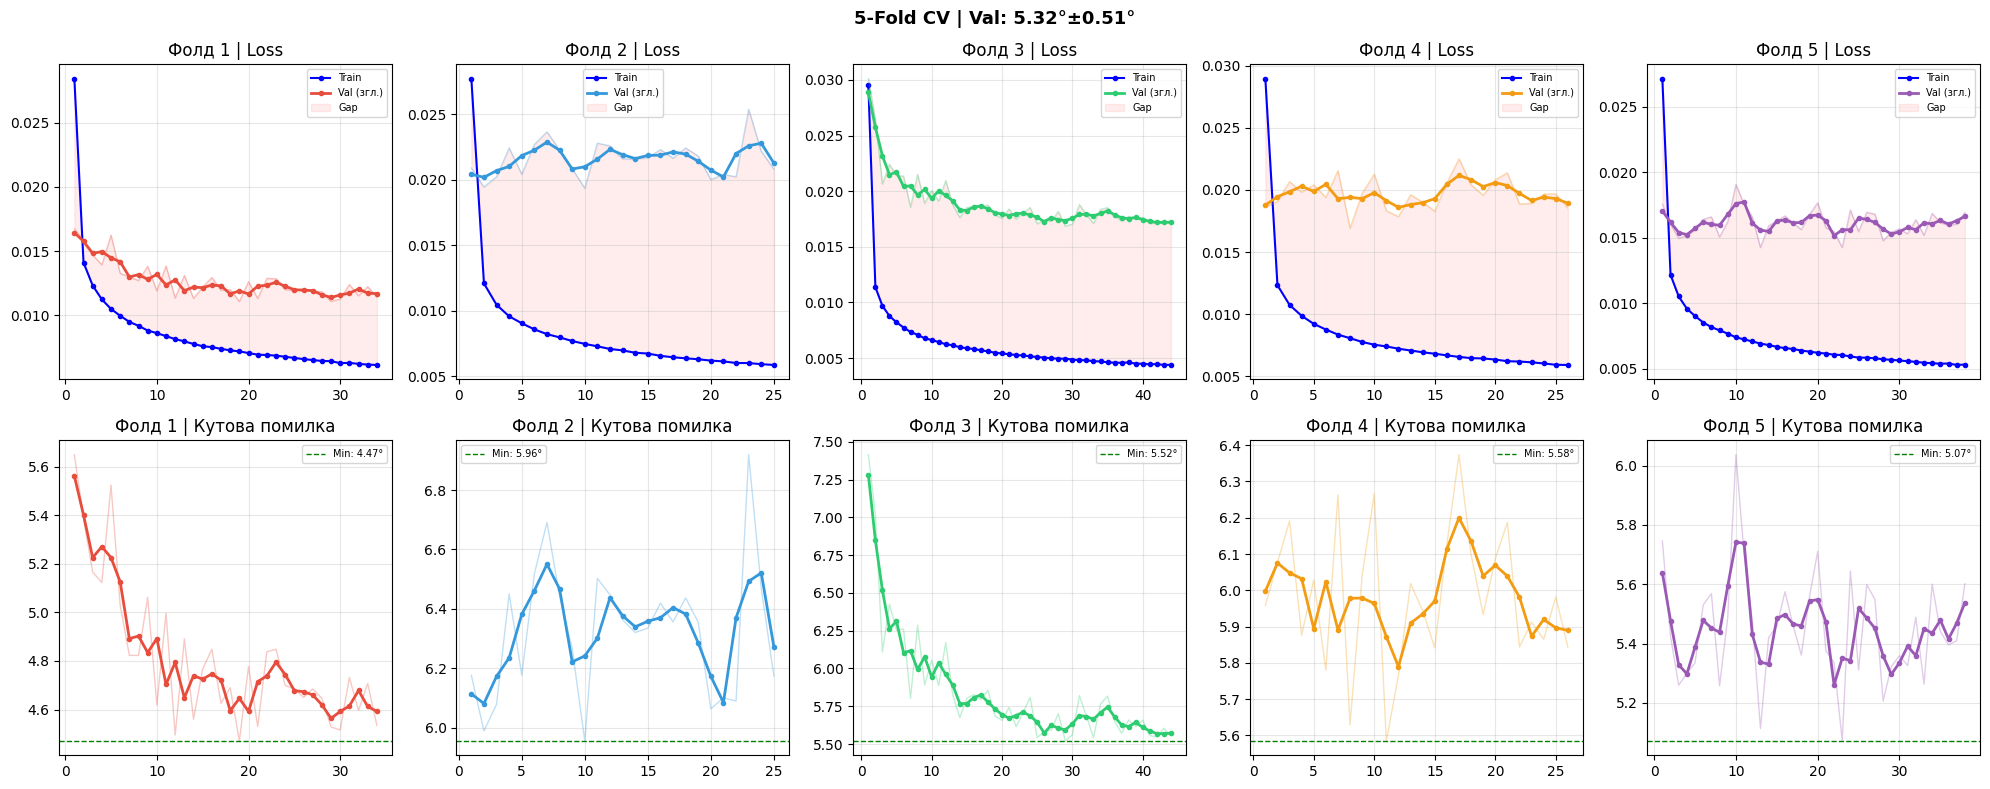

Збережено: cv_curves_14k.png


In [ ]:
# Графіки CV

fig, axes = plt.subplots(2, n_folds, figsize=(20, 8))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for fi, fh in enumerate(all_fold_histories):
    ep = range(1, len(fh['train_loss']) + 1)

    ax = axes[0][fi]
    ax.plot(ep, fh['train_loss'], 'b-o', ms=3, label='Train')
    ax.plot(ep, fh['val_loss'], color=colors[fi], alpha=0.3, lw=1)
    ax.plot(ep, uniform_filter1d(fh['val_loss'], 3),
            color=colors[fi], lw=2, marker='o', ms=3, label='Val (згл.)')
    ax.fill_between(ep, fh['train_loss'], fh['val_loss'],
                    alpha=0.07, color='red', label='Gap')
    ax.set_title(f'Фолд {fi+1} | Loss')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    ax2 = axes[1][fi]
    ax2.plot(ep, fh['val_angular_error'], color=colors[fi], alpha=0.3, lw=1)
    ax2.plot(ep, uniform_filter1d(fh['val_angular_error'], 3),
             color=colors[fi], lw=2, marker='o', ms=3)
    ax2.axhline(min(fh['val_angular_error']), color='green', ls='--', lw=1,
                label=f"Min: {min(fh['val_angular_error']):.2f}°")
    ax2.set_title(f'Фолд {fi+1} | Кутова помилка')
    ax2.legend(fontsize=7)
    ax2.grid(True, alpha=0.3)

plt.suptitle(
    f'5-Fold CV | Val: {np.mean(ang_errors):.2f}°±{np.std(ang_errors):.2f}°',
    fontsize=13, fontweight='bold',
)
plt.tight_layout()
plt.savefig('cv_curves_14k.png', dpi=150, bbox_inches='tight')
plt.show()
print("Збережено: cv_curves_14k.png")

In [ ]:
# Фінальне тестування — АНСАМБЛЬ (усереднення 5 моделей)

def evaluate_on_test_set_simple(model, loader, device, dataset):
    model.eval()
    total_loss, n = 0.0, 0
    all_pred, all_tgt = [], []

    with torch.no_grad():
        for imgs, gazes, poses, _ in loader:
            imgs, gazes, poses = imgs.to(device), gazes.to(device), poses.to(device)
            out = model(imgs, poses)
            total_loss += criterion(out, gazes).item() * imgs.size(0)
            n += imgs.size(0)
            all_pred.append(out.cpu())
            all_tgt.append(gazes.cpu())

    all_pred = torch.cat(all_pred, dim=0)
    all_tgt  = torch.cat(all_tgt,  dim=0)
    ang_err  = calculate_angular_error(all_pred, all_tgt, dataset)

    return {
        'angular_error': ang_err,
        'loss':          total_loss / n,
        'predictions':   all_pred,
        'predictions_denorm': denormalize_gaze_batch(all_pred, dataset),
        'targets_denorm':     denormalize_gaze_batch(all_tgt,  dataset),
        'n': n,
        'yaw_error':   torch.abs(
            denormalize_gaze_batch(all_pred, dataset)[:, 0] -
            denormalize_gaze_batch(all_tgt,  dataset)[:, 0]
        ).mean().item(),
        'pitch_error': torch.abs(
            denormalize_gaze_batch(all_pred, dataset)[:, 1] -
            denormalize_gaze_batch(all_tgt,  dataset)[:, 1]
        ).mean().item(),
    }

# Передбачення кожної з 5 моделей
all_test_metrics = []
all_test_outputs = []

print(f"Збір передбачень з {len(fold_results)} моделей...")

for fold_info in fold_results:
    f_idx = fold_info['fold']
    temp_model = GazeEstimationNet(dropout_rate=0.5).to(device)
    temp_model.load_state_dict(fold_info['best_state'])

    res = evaluate_on_test_set_simple(temp_model, test_loader, device, test_dataset)
    all_test_metrics.append(res['angular_error'])
    all_test_outputs.append(res)
    print(f"  Фолд {f_idx}: Test Angular Error = {res['angular_error']:.2f}°")

all_preds_norm = torch.stack([
    out['predictions'] for out in all_test_outputs
])

ensemble_pred_norm = all_preds_norm.mean(dim=0)
targets_norm = all_test_outputs[0]['predictions'] * 0

all_tgt_list = []
first_model = GazeEstimationNet(dropout_rate=0.5).to(device)
first_model.load_state_dict(fold_results[0]['best_state'])
first_model.eval()
with torch.no_grad():
    for imgs, gazes, poses, _ in test_loader:
        all_tgt_list.append(gazes)
all_tgt_norm = torch.cat(all_tgt_list, dim=0)

# Метрики ансамблю
ensemble_ang_err = calculate_angular_error(
    ensemble_pred_norm, all_tgt_norm, test_dataset
)
ensemble_pred_d = denormalize_gaze_batch(ensemble_pred_norm, test_dataset)
ensemble_tgt_d  = denormalize_gaze_batch(all_tgt_norm,       test_dataset)

ensemble_yaw_err   = torch.abs(ensemble_pred_d[:, 0] - ensemble_tgt_d[:, 0]).mean().item()
ensemble_pitch_err = torch.abs(ensemble_pred_d[:, 1] - ensemble_tgt_d[:, 1]).mean().item()

best_fold_idx  = int(np.argmin(all_test_metrics))
best_single    = all_test_outputs[best_fold_idx]

print("\n" + "="*60)
print("РЕЗУЛЬТАТИ ТЕСТУВАННЯ:")
print(f"\n  Окремі моделі:")
for i, err in enumerate(all_test_metrics):
    marker = " ← найкраща" if i == best_fold_idx else ""
    print(f"    Фолд {i+1}: {err:.2f}°{marker}")
print(f"\n  Середнє по фолдах:   {np.mean(all_test_metrics):.2f}° ± {np.std(all_test_metrics):.2f}°")
print(f"\n  АНСАМБЛЬ (усереднення передбачень):")
print(f"    Angular Error:  {ensemble_ang_err:.2f}°")
print(f"    Yaw MAE:        {np.degrees(ensemble_yaw_err):.2f}°")
print(f"    Pitch MAE:      {np.degrees(ensemble_pitch_err):.2f}°")
print("="*60)

test_results = {
    'angular_error':      ensemble_ang_err,
    'predictions_denorm': ensemble_pred_d,
    'targets_denorm':     ensemble_tgt_d,
    'yaw_error':          ensemble_yaw_err,
    'pitch_error':        ensemble_pitch_err,
    'n':                  len(ensemble_pred_norm),
}

import os
from google.colab import drive

print("\nПідключення Google Диску для надійного збереження...")

drive.mount('/content/drive')


save_dir = '/content/drive/MyDrive/Курсова_Моделі'
os.makedirs(save_dir, exist_ok=True)

print(f"\nЗбереження файлів на Google Диск у папку: {save_dir} ...")

stats_path = os.path.join(save_dir, 'ensemble_statistics.pth')
torch.save({
    'ensemble_angular_error': ensemble_ang_err,
    'per_fold_errors':        all_test_metrics,
    'cv_mean_angular':        float(np.mean(ang_errors)),
    'cv_std_angular':         float(np.std(ang_errors)),
    'gaze_ranges':            GLOBAL_GAZE_RANGES,
    'img_mean':               IMG_MEAN,
    'img_std':                IMG_STD,
    'config': {
        'n_folds':        n_folds,
        'train_samples':  SAMPLES_TRAIN_CV,
        'batch_size':     BATCH_SIZE,
        'lr':             LEARNING_RATE,
        'epochs_max':     NUM_EPOCHS_CV,
    }
}, stats_path)

for fold_info in fold_results:
    f_idx = fold_info['fold']
    file_name = f'model_fold_{f_idx}.pth'
    file_path = os.path.join(save_dir, file_name)

    torch.save(fold_info['best_state'], file_path)
    print(f"Збережено ваги фолду {f_idx} у '{file_path}'")

Збір передбачень з 5 моделей...
  Фолд 1: Test Angular Error = 5.52°
  Фолд 2: Test Angular Error = 5.54°
  Фолд 3: Test Angular Error = 5.62°
  Фолд 4: Test Angular Error = 5.67°
  Фолд 5: Test Angular Error = 5.81°

РЕЗУЛЬТАТИ ТЕСТУВАННЯ:

  Окремі моделі:
    Фолд 1: 5.52° ← найкраща
    Фолд 2: 5.54°
    Фолд 3: 5.62°
    Фолд 4: 5.67°
    Фолд 5: 5.81°

  Середнє по фолдах:   5.63° ± 0.10°

  АНСАМБЛЬ (усереднення передбачень):
    Angular Error:  5.40°
    Yaw MAE:        4.03°
    Pitch MAE:      2.77°

Підключення Google Диску для надійного збереження...
Mounted at /content/drive

Збереження файлів на Google Диск у папку: /content/drive/MyDrive/Курсова_Моделі ...
✅ Збережено статистику у '/content/drive/MyDrive/Курсова_Моделі/ensemble_statistics.pth'
✅ Збережено ваги фолду 1 у '/content/drive/MyDrive/Курсова_Моделі/model_fold_1.pth'
✅ Збережено ваги фолду 2 у '/content/drive/MyDrive/Курсова_Моделі/model_fold_2.pth'
✅ Збережено ваги фолду 3 у '/content/drive/MyDrive/Курсова_Моде

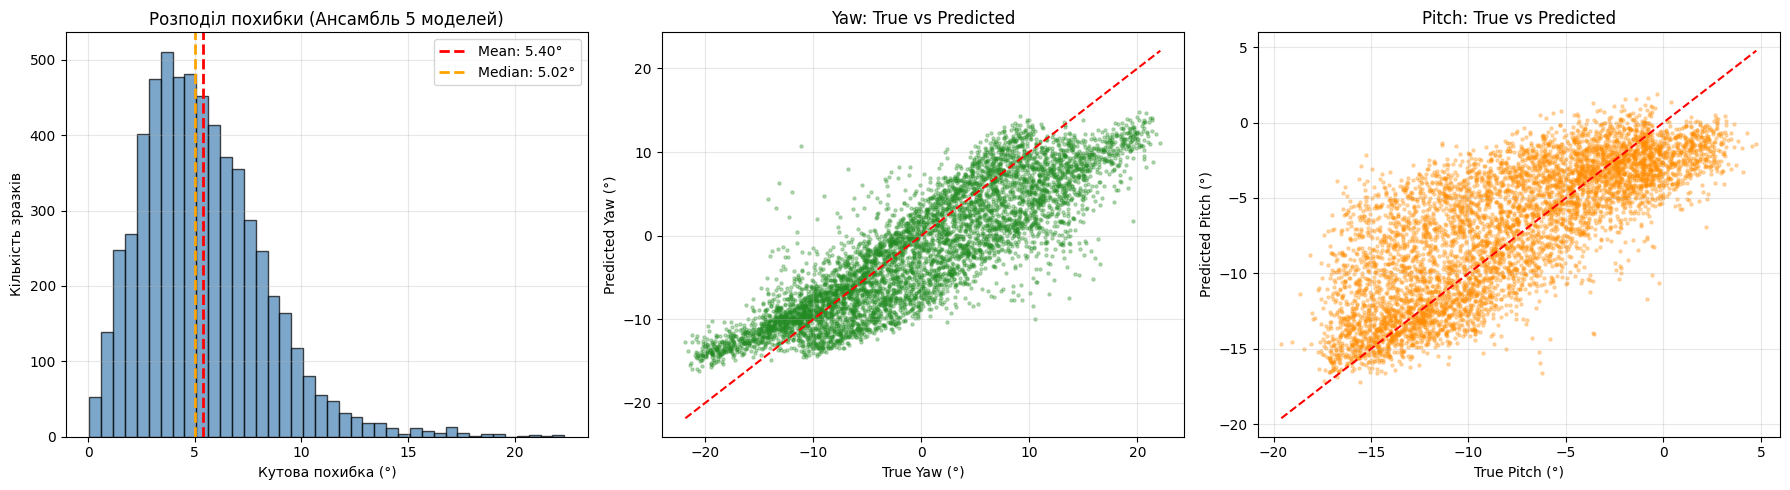


ДЕТАЛЬНА СТАТИСТИКА (BEST MODEL):
  Зразків у тесті:  5,996
  Середня похибка:  5.40°
  Медіана:          5.02°
  75-й процентиль:  7.07°
  Yaw MAE:          4.03°
  Pitch MAE:        2.77°

ТОЧНІСТЬ ЗА ПОРОГАМИ:
  Допустима похибка ±5°: 49.8% зразків
  Допустима похибка ±10°: 93.9% зразків
  Допустима похибка ±15°: 99.0% зразків

ПІДСУМОК ДЛЯ КУРСОВОЇ (АНСАМБЛЬ):
  CV Angular Error:   5.32° ± 0.51°
  Test Angular Error: 5.40°


In [ ]:
# Візуалізація результатів тестування

pred_dnorm   = test_results['predictions_denorm']
target_dnorm = test_results['targets_denorm']

per_sample_errors = []
for i in range(len(pred_dnorm)):
    p, t = pred_dnorm[i].numpy(), target_dnorm[i].numpy()
    pv = np.array([-np.sin(p[0])*np.cos(p[1]), -np.sin(p[1]), -np.cos(p[0])*np.cos(p[1])])
    tv = np.array([-np.sin(t[0])*np.cos(t[1]), -np.sin(t[1]), -np.cos(t[0])*np.cos(t[1])])
    per_sample_errors.append(np.degrees(np.arccos(np.clip(np.dot(pv, tv), -1, 1))))
per_sample_errors = np.array(per_sample_errors)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(per_sample_errors, bins=40, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(np.mean(per_sample_errors), color='red', ls='--', lw=2,
                label=f'Mean: {np.mean(per_sample_errors):.2f}°')
axes[0].axvline(np.median(per_sample_errors), color='orange', ls='--', lw=2,
                label=f'Median: {np.median(per_sample_errors):.2f}°')
axes[0].set_title('Розподіл похибки (Ансамбль 5 моделей)')
axes[0].set_xlabel('Кутова похибка (°)')
axes[0].set_ylabel('Кількість зразків')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

y_t, y_p = np.degrees(target_dnorm[:, 0]), np.degrees(pred_dnorm[:, 0])
axes[1].scatter(y_t, y_p, alpha=0.3, s=5, color='forestgreen')
axes[1].plot([y_t.min(), y_t.max()], [y_t.min(), y_t.max()], 'r--', lw=1.5)
axes[1].set_title('Yaw: True vs Predicted')
axes[1].set_xlabel('True Yaw (°)')
axes[1].set_ylabel('Predicted Yaw (°)')
axes[1].grid(True, alpha=0.3)

p_t, p_p = np.degrees(target_dnorm[:, 1]), np.degrees(pred_dnorm[:, 1])
axes[2].scatter(p_t, p_p, alpha=0.3, s=5, color='darkorange')
axes[2].plot([p_t.min(), p_t.max()], [p_t.min(), p_t.max()], 'r--', lw=1.5)
axes[2].set_title('Pitch: True vs Predicted')
axes[2].set_xlabel('True Pitch (°)')
axes[2].set_ylabel('Predicted Pitch (°)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('final_evaluation_plots_14k.png', dpi=150)
plt.show()

print(f"\nДЕТАЛЬНА СТАТИСТИКА (BEST MODEL):")
print(f"  Зразків у тесті:  {len(per_sample_errors):,}")
print(f"  Середня похибка:  {np.mean(per_sample_errors):.2f}°")
print(f"  Медіана:          {np.median(per_sample_errors):.2f}°")
print(f"  75-й процентиль:  {np.percentile(per_sample_errors, 75):.2f}°")
print(f"  Yaw MAE:          {np.degrees(test_results['yaw_error']):.2f}°")
print(f"  Pitch MAE:        {np.degrees(test_results['pitch_error']):.2f}°")

print(f"\nТОЧНІСТЬ ЗА ПОРОГАМИ:")
for thr in [5, 10, 15]:
    acc = np.mean(per_sample_errors <= thr) * 100
    print(f"  Допустима похибка ±{thr}°: {acc:.1f}% зразків")

print(f"\nПІДСУМОК (АНСАМБЛЬ):")
print(f"  CV Angular Error:   {np.mean(ang_errors):.2f}° ± {np.std(ang_errors):.2f}°")
print(f"  Test Angular Error: {test_results['angular_error']:.2f}°")

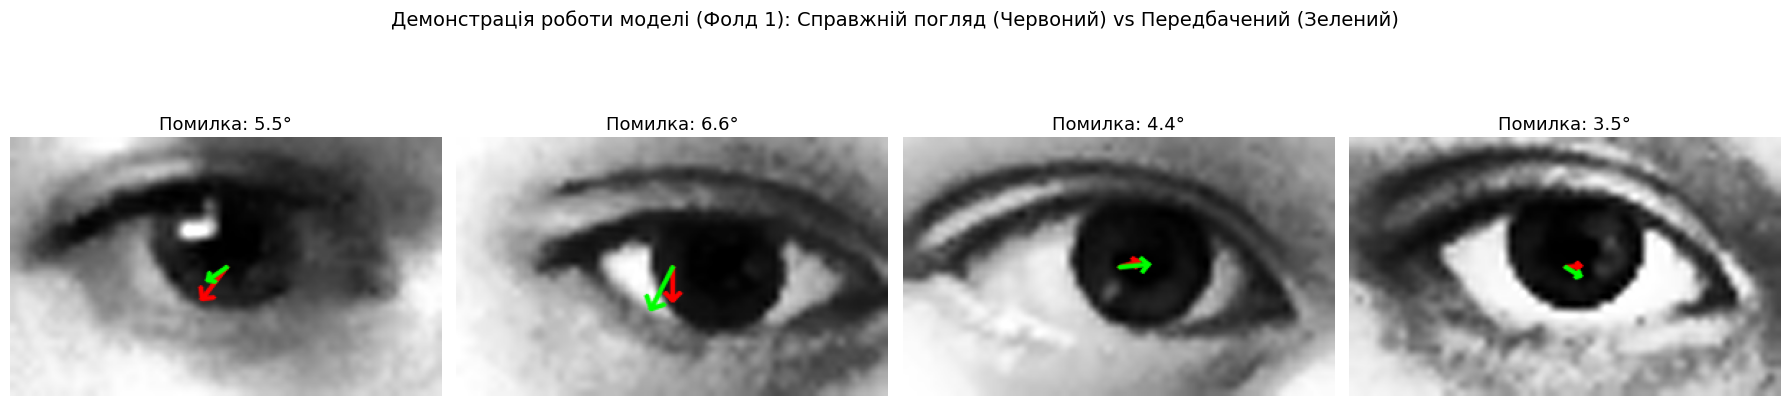

In [ ]:
import cv2

def draw_gaze_arrow(image_bgr, yaw, pitch, color, length=35, thickness=2):
    h, w = image_bgr.shape[:2]
    c_x, c_y = w // 2, h // 2
    dx = -length * np.sin(yaw)
    dy = -length * np.sin(pitch)
    end_point = (int(c_x + dx), int(c_y + dy))
    cv2.arrowedLine(image_bgr, (c_x, c_y), end_point,
                    color, thickness, tipLength=0.3, line_type=cv2.LINE_AA)
    return image_bgr

best_model_to_show = GazeEstimationNet(dropout_rate=0.5).to(device)
best_model_to_show.load_state_dict(fold_results[0]['best_state'])
best_model_to_show.eval()

indices = np.random.choice(len(test_dataset), 4, replace=False)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Демонстрація роботи моделі (Фолд 1): Справжній погляд (Червоний) vs Передбачений (Зелений)", fontsize=14)

SCALE = 5
for i, idx in enumerate(indices):
    img_tensor, gt_gaze_tensor, pose_tensor, _ = test_dataset[idx]

    with torch.no_grad():
        pred_gaze_norm = best_model_to_show(
            img_tensor.unsqueeze(0).to(device),
            pose_tensor.unsqueeze(0).to(device)
        )

    pred_gaze = denormalize_gaze_batch(pred_gaze_norm, test_dataset).cpu().numpy()[0]
    gt_gaze = test_dataset.denormalize_gaze(gt_gaze_tensor.numpy())

    img_show = img_tensor.squeeze().numpy() * test_dataset.img_std + test_dataset.img_mean
    img_show = np.clip(img_show * 255, 0, 255).astype(np.uint8)
    img_bgr = cv2.cvtColor(img_show, cv2.COLOR_GRAY2BGR)

    h, w = img_bgr.shape[:2]
    img_bgr = cv2.resize(img_bgr, (w * SCALE, h * SCALE), interpolation=cv2.INTER_CUBIC)

    img_bgr = draw_gaze_arrow(img_bgr, gt_gaze[0], gt_gaze[1],
                               color=(0, 0, 255), length=120, thickness=2)
    img_bgr = draw_gaze_arrow(img_bgr, pred_gaze[0], pred_gaze[1],
                               color=(0, 255, 0), length=120, thickness=2)

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img_rgb)
    axes[i].axis('off')
    axes[i].set_title(f"Помилка: {per_sample_errors[idx]:.1f}°", fontsize=13)

plt.tight_layout()
plt.savefig('gaze_demo.png', dpi=150, bbox_inches='tight')
plt.show()